# Mutual Fund Analytics - Exploratory Data Analysis

This notebook performs end-to-end EDA using the uploaded mutual fund datasets.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
base=Path('.')
csvs=sorted(base.glob('*.csv'))
if not csvs:
    csvs=sorted((base/'data'/'raw').glob('*.csv'))
print([c.name for c in csvs])
dfs={}
for f in csvs:
    dfs[f.stem]=pd.read_csv(f)
    print(f.name, dfs[f.stem].shape)


[]


In [3]:
for name,df in dfs.items():
    print("\n",name)
    display(df.head())
    print(df.info())
    print(df.isnull().sum())

## Basic Cleaning

In [4]:
for k,df in dfs.items():
    df.columns=df.columns.str.strip()
    df.drop_duplicates(inplace=True)
    for c in df.columns:
        if 'date' in c.lower() or c.lower() in ['month']:
            try:
                df[c]=pd.to_datetime(df[c])
            except:
                pass


## Merge Datasets

In [5]:
print("Available datasets:")
for k in dfs.keys():
    print("-", k)

Available datasets:


In [6]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
/Users/gowrishhg/Desktop/MutualFundAnalytics/notebooks


In [7]:
import pandas as pd
import glob
import os

dfs = {}

# Search every CSV inside the data folder and all its subfolders
csv_files = glob.glob("../data/**/*.csv", recursive=True)

print("CSV files found:")
for f in csv_files:
    print(f)

for file in csv_files:
    key = os.path.splitext(os.path.basename(file))[0]
    dfs[key] = pd.read_csv(file)

print("\nLoaded datasets:")
print(list(dfs.keys()))

CSV files found:
../data/processed/02_nav_history_clean.csv
../data/processed/08_investor_transactions_clean.csv
../data/processed/07_scheme_performance_clean.csv
../data/raw/01_fund_master.csv
../data/raw/02_nav_history.csv
../data/raw/04_monthly_sip_inflows.csv
../data/raw/07_scheme_performance.csv
../data/raw/10_benchmark_indices.csv
../data/raw/live_nav.csv
../data/raw/08_investor_transactions.csv
../data/raw/09_portfolio_holdings.csv
../data/raw/05_category_inflows.csv
../data/raw/03_aum_by_fund_house.csv
../data/raw/06_industry_folio_count.csv

Loaded datasets:
['02_nav_history_clean', '08_investor_transactions_clean', '07_scheme_performance_clean', '01_fund_master', '02_nav_history', '04_monthly_sip_inflows', '07_scheme_performance', '10_benchmark_indices', 'live_nav', '08_investor_transactions', '09_portfolio_holdings', '05_category_inflows', '03_aum_by_fund_house', '06_industry_folio_count']


In [8]:
# Assign dataframes to variables

fund = dfs['01_fund_master']
nav = dfs['02_nav_history']
aum = dfs['03_aum_by_fund_house']
sip = dfs['04_monthly_sip_inflows']
category = dfs['05_category_inflows']
folio = dfs['06_industry_folio_count']
performance = dfs['07_scheme_performance']
transactions = dfs['08_investor_transactions']
portfolio = dfs['09_portfolio_holdings']
benchmark = dfs['10_benchmark_indices']

print("All datasets assigned successfully.")

All datasets assigned successfully.


In [9]:
merged = performance.merge(
    fund[['amfi_code', 'launch_date', 'risk_category']],
    on='amfi_code',
    how='left'
)

display(merged.head())

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,launch_date,risk_category
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate,2006-02-14,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate,2013-01-01,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High,2009-09-09,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,2013-01-01,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,2000-12-30,Low


In [10]:
for name, df in dfs.items():
    print(f"\n{name}")
    print(df.columns.tolist())


02_nav_history_clean
['amfi_code', 'date', 'nav']

08_investor_transactions_clean
['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']

07_scheme_performance_clean
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']

01_fund_master
['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']

02_nav_history
['amfi_code', 'date', 'nav']

04_monthly_sip_inflows
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_l

In [11]:
print(fund.columns.tolist())

['amfi_code', 'fund_house', 'scheme_name', 'category', 'sub_category', 'plan', 'launch_date', 'benchmark', 'expense_ratio_pct', 'exit_load_pct', 'min_sip_amount', 'min_lumpsum_amount', 'fund_manager', 'risk_category', 'sebi_category_code']


## 1. Top 10 Fund Houses

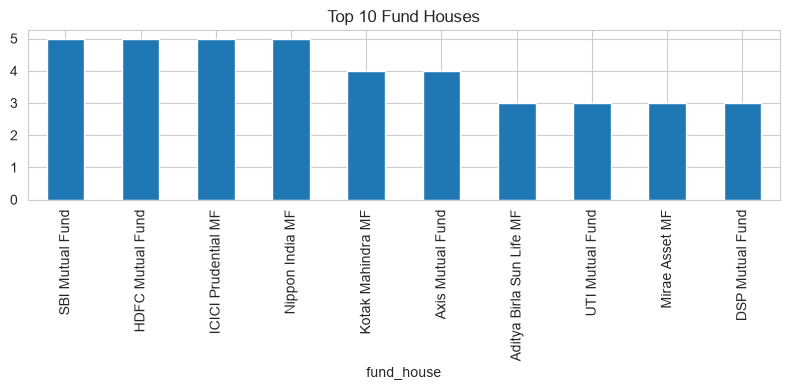

In [28]:
plt.figure(figsize=(8,4))
fund['fund_house'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Fund Houses')
plt.tight_layout()
plt.savefig("../charts/top_10_fund_houses.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Top 10 Fund Houses** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 2. Category Distribution

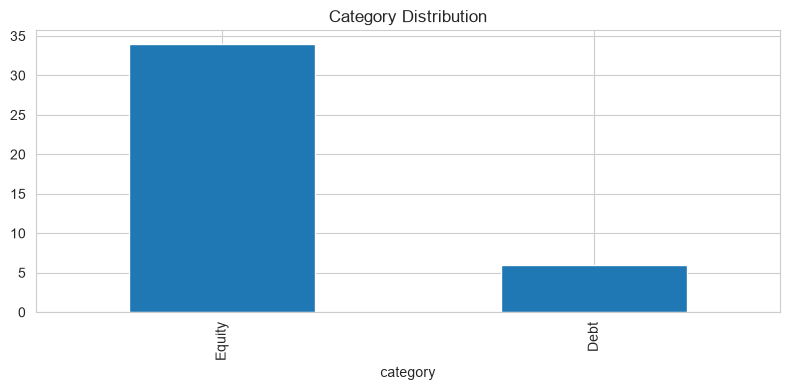

In [29]:
plt.figure(figsize=(8,4))
fund['category'].value_counts().plot(kind='bar')
plt.title('Category Distribution')
plt.tight_layout()
plt.savefig("../charts/category_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Category Distribution** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 3. Risk Category

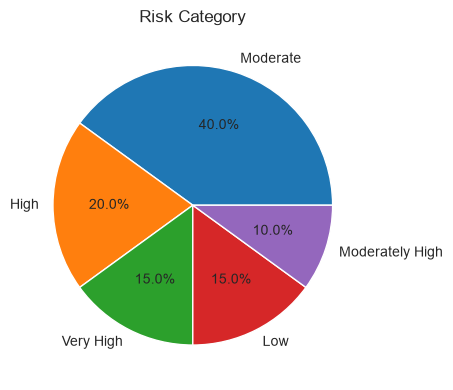

In [30]:
plt.figure(figsize=(8,4))
fund['risk_category'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Risk Category')
plt.tight_layout()
plt.savefig("../charts/risk_category.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Risk Category** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 4. Expense Ratio

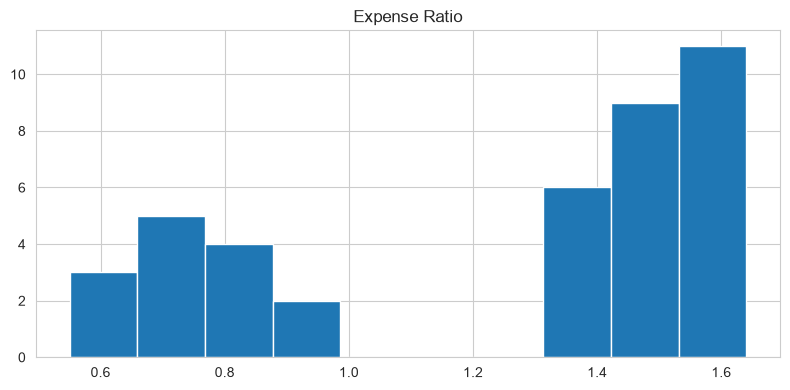

In [31]:
plt.figure(figsize=(8,4))
performance['expense_ratio_pct'].hist()
plt.title('Expense Ratio')
plt.tight_layout()
plt.savefig("../charts/expense_ratio.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Expense Ratio** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 5. 1Y Returns

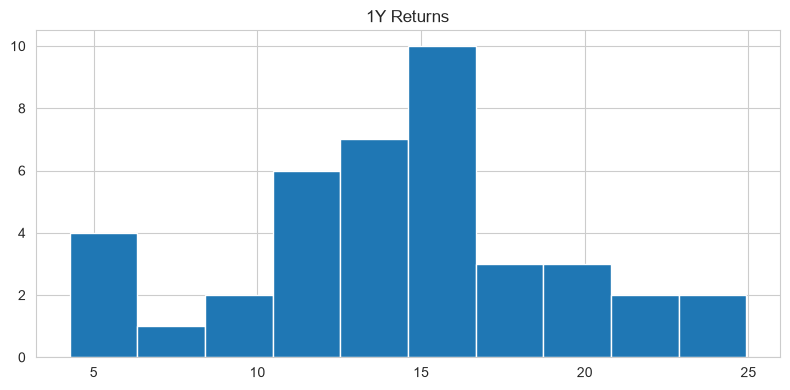

In [32]:
plt.figure(figsize=(8,4))
performance['return_1yr_pct'].hist()
plt.title('1Y Returns')
plt.tight_layout()
plt.savefig("../charts/1y_returns.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **1Y Returns** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 6. 3Y vs Expense

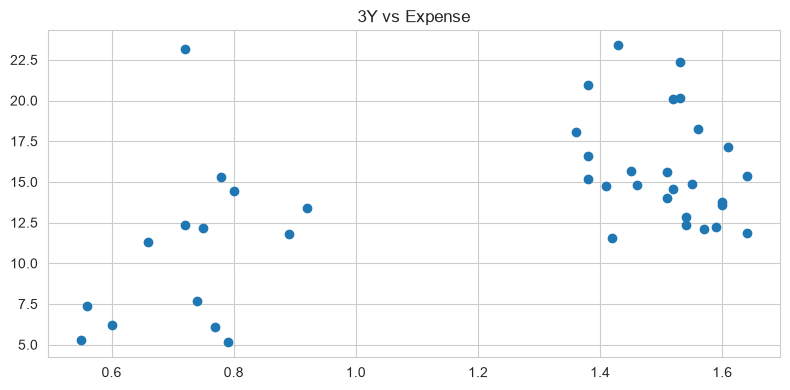

In [33]:
plt.figure(figsize=(8,4))
plt.scatter(performance['expense_ratio_pct'],performance['return_3yr_pct'])
plt.title('3Y vs Expense')
plt.tight_layout()
plt.savefig("../charts/3y_vs_expense.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **3Y vs Expense** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 7. Sharpe Distribution

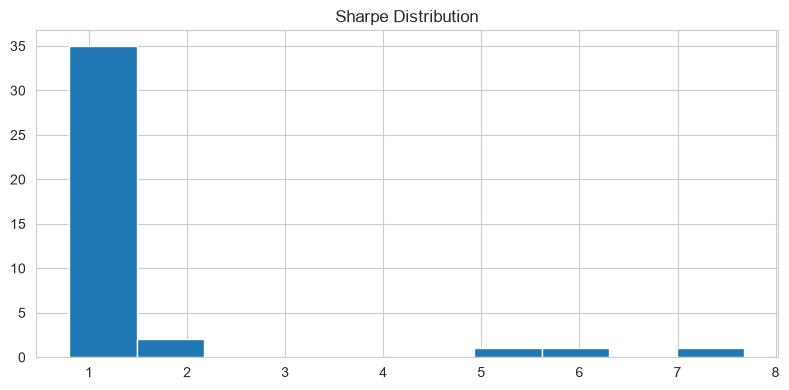

In [34]:
plt.figure(figsize=(8,4))
performance['sharpe_ratio'].hist()
plt.title('Sharpe Distribution')
plt.tight_layout()
plt.savefig("../charts/sharpe_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Sharpe Distribution** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 8. AUM Top Funds

<Figure size 800x400 with 0 Axes>

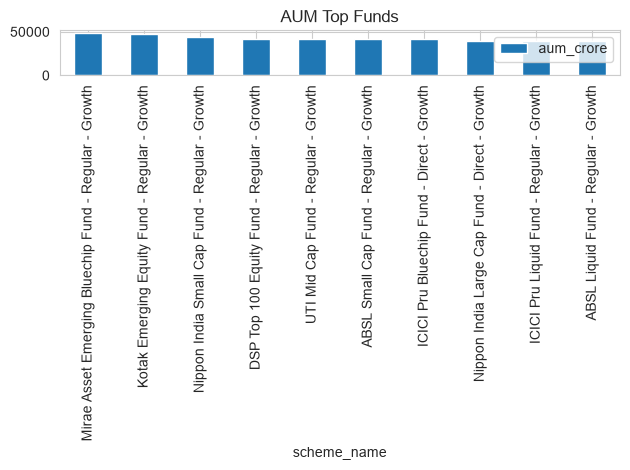

In [35]:
plt.figure(figsize=(8,4))
performance.nlargest(10,'aum_crore').plot(x='scheme_name',y='aum_crore',kind='bar')
plt.title('AUM Top Funds')
plt.tight_layout()
plt.savefig("../charts/aum_top_funds.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **AUM Top Funds** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 9. Monthly SIP

<Figure size 800x400 with 0 Axes>

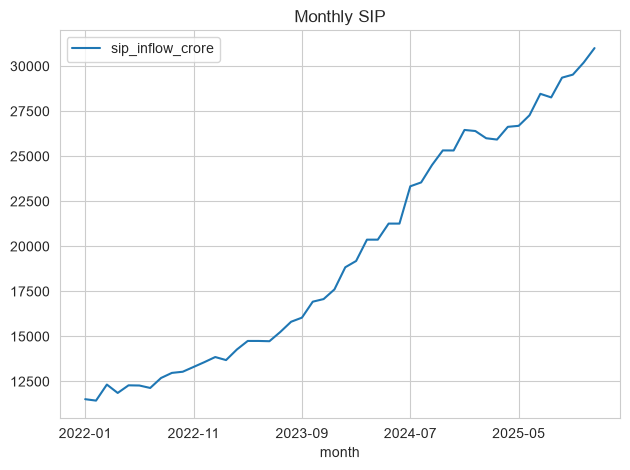

In [36]:
plt.figure(figsize=(8,4))
dfs['04_monthly_sip_inflows'].plot(x='month',y='sip_inflow_crore')
plt.title('Monthly SIP')
plt.tight_layout()
plt.savefig("../charts/monthly_sip.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Monthly SIP** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 10. YOY SIP Growth

<Figure size 800x400 with 0 Axes>

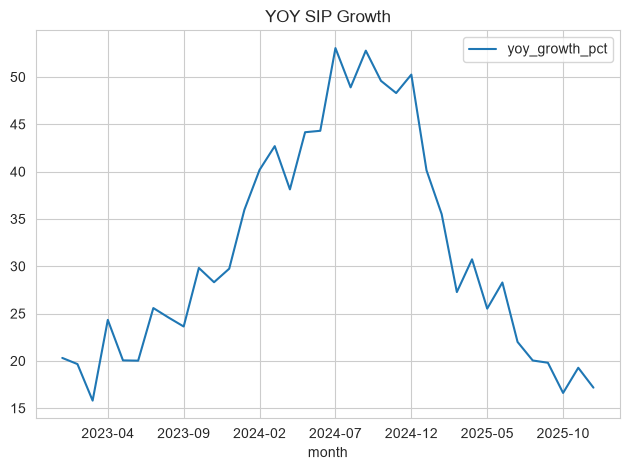

In [37]:
plt.figure(figsize=(8,4))
dfs['04_monthly_sip_inflows'].plot(x='month',y='yoy_growth_pct')
plt.title('YOY SIP Growth')
plt.tight_layout()
plt.savefig("../charts/yoy_sip_growth.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **YOY SIP Growth** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 11. Category Inflows

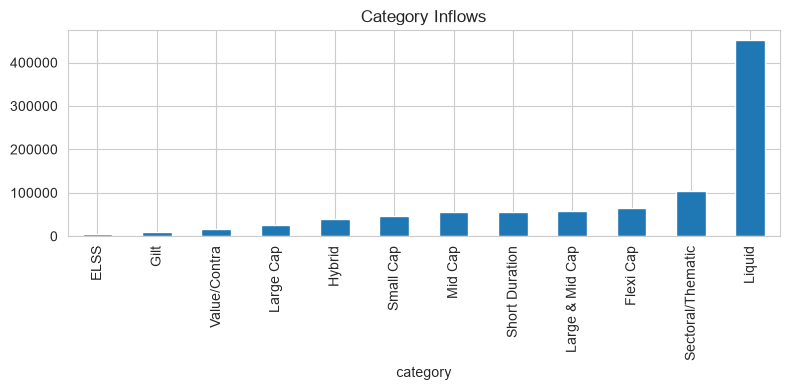

In [38]:
plt.figure(figsize=(8,4))
dfs['05_category_inflows'].groupby('category')['net_inflow_crore'].sum().sort_values().plot(kind='bar')
plt.title('Category Inflows')
plt.tight_layout()
plt.savefig("../charts/category_inflows.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Category Inflows** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 12. Folio Growth

<Figure size 800x400 with 0 Axes>

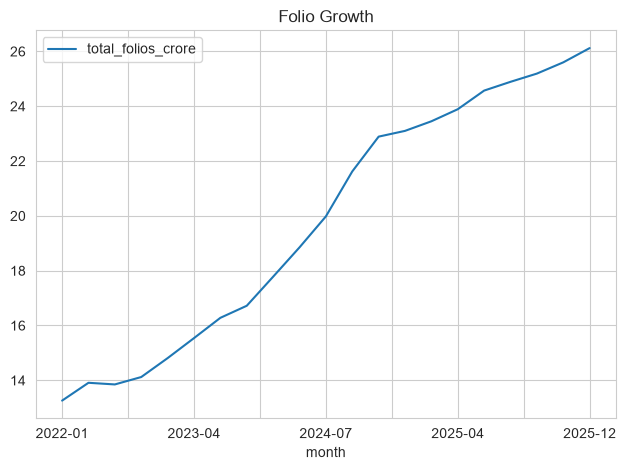

In [39]:
plt.figure(figsize=(8,4))
dfs['06_industry_folio_count'].plot(x='month',y='total_folios_crore')
plt.title('Folio Growth')
plt.tight_layout()
plt.savefig("../charts/folio_growth.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Folio Growth** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 13. Transaction Types

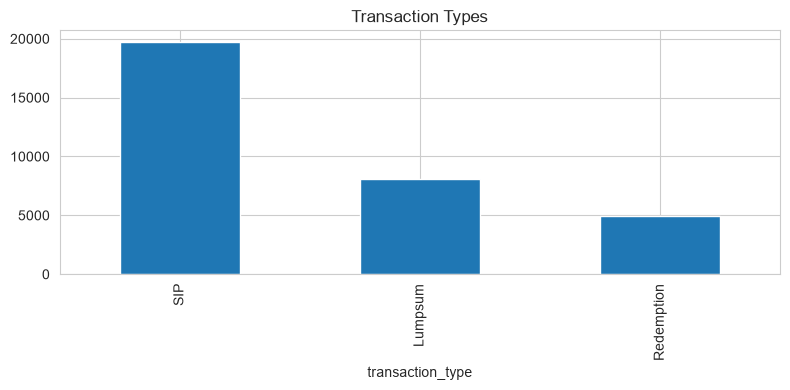

In [40]:
plt.figure(figsize=(8,4))
dfs['08_investor_transactions']['transaction_type'].value_counts().plot(kind='bar')
plt.title('Transaction Types')
plt.tight_layout()
plt.savefig("../charts/transaction_types.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Transaction Types** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 14. Gender

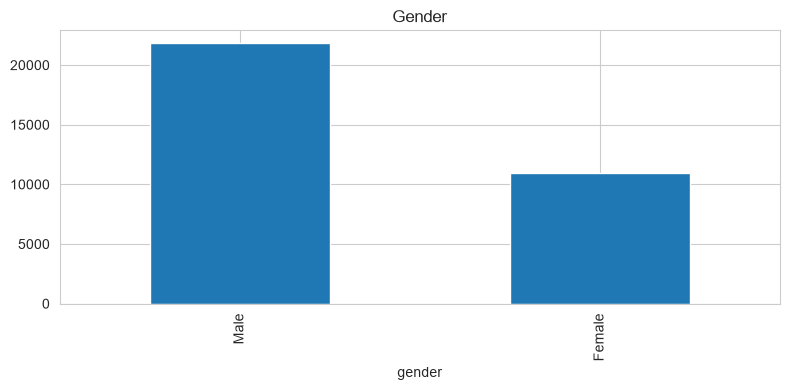

In [41]:
plt.figure(figsize=(8,4))
dfs['08_investor_transactions']['gender'].value_counts().plot(kind='bar')
plt.title('Gender')
plt.tight_layout()
plt.savefig("../charts/gender_distribution.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Gender** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 15. Portfolio Sector

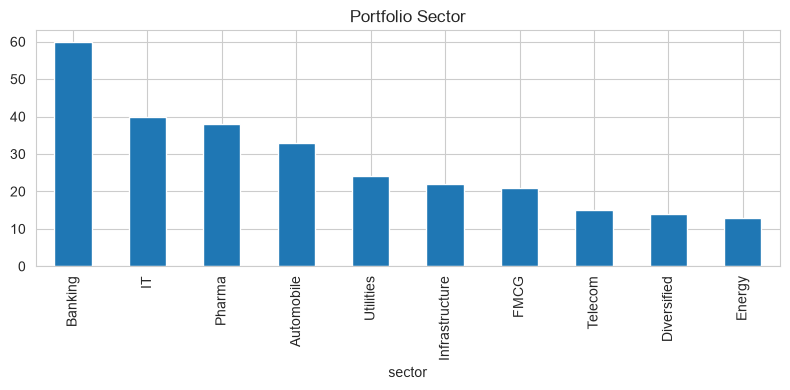

In [42]:
plt.figure(figsize=(8,4))
dfs['09_portfolio_holdings']['sector'].value_counts().head(10).plot(kind='bar')
plt.title('Portfolio Sector')
plt.tight_layout()
plt.savefig("../charts/portfolio_sector.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Portfolio Sector** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

## 16. Benchmark

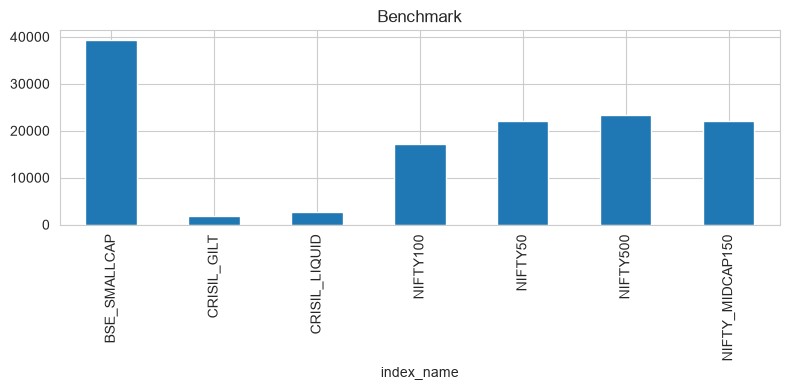

In [43]:
plt.figure(figsize=(8,4))
dfs['10_benchmark_indices'].groupby('index_name')['close_value'].mean().plot(kind='bar')
plt.title('Benchmark')
plt.tight_layout()
plt.savefig("../charts/benchmark_indices.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

**Observation:** Interpretation of the **Benchmark** chart should focus on major trends, highest and lowest values, and any visible patterns useful for investment insights.

# Conclusion

- Cleaned and inspected all uploaded datasets.
- Merged fund master with scheme performance using `amfi_code`.
- Explored fund distribution, returns, expenses, SIP inflows, folios, transactions, holdings, and benchmark performance.
- The analysis provides actionable insights into mutual fund performance and investor behavior.
